# 12.1 — VaR/ES: paramétrico, histórico, Monte Carlo

Arranca M12. **VaR** al nivel $\alpha$: el cuantil $(1-\alpha)$ de la distribución de
pérdidas sobre un horizonte $h$. **ES** (Expected Shortfall): el promedio de la pérdida
condicional a superar el VaR — **coherente** (subaditivo), a diferencia de VaR, que no lo
es en general. Tres métodos de cálculo (paramétrico, histórico, Monte Carlo) coinciden
para un portafolio lineal, pero divergen cuando hay convexidad (opciones).

## 0. Configuración

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

from qflib.black import bs_price, bs_delta
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

alpha = 0.99
h = 10 / 252  # horizonte de 10 dias habiles
z_alpha = norm.ppf(alpha)

## 1. Portafolio lineal: paramétrico vs histórico

Posición spot simple ($S_0=100$, $\mu=0$, $\sigma=20\%$). VaR paramétrico (normal):
$VaR_\alpha=S_0\left(z_\alpha\sigma\sqrt h-\mu h\right)$; ES paramétrico normal:
$ES_\alpha=S_0\sigma\sqrt h\,\frac{\phi(z_\alpha)}{1-\alpha}-S_0\mu h$. VaR/ES histórico:
percentil empírico de una serie de retornos simulados (sin asumir normalidad — aquí, por
construcción, SÍ son normales, así que ambos métodos deben coincidir).

In [2]:
S0, mu, sigma = 100.0, 0.0, 0.20

VaR_param = S0 * (z_alpha * sigma * np.sqrt(h) - mu * h)
ES_param = S0 * sigma * np.sqrt(h) * norm.pdf(z_alpha) / (1 - alpha) - S0 * mu * h

n_hist = 200_000
rets = rng.normal(mu * h, sigma * np.sqrt(h), n_hist)
losses_linear = -S0 * rets
VaR_hist = np.quantile(losses_linear, alpha)
ES_hist = losses_linear[losses_linear >= VaR_hist].mean()

print(f"VaR parametrico={VaR_param:.4f}  VaR historico={VaR_hist:.4f}  "
      f"diff relativa={abs(VaR_param-VaR_hist)/VaR_param:.2%}")
print(f"ES parametrico={ES_param:.4f}  ES historico={ES_hist:.4f}  "
      f"diff relativa={abs(ES_param-ES_hist)/ES_param:.2%}")
print(f"\nES >= VaR (parametrico): {ES_param >= VaR_param}  (historico): {ES_hist >= VaR_hist}")

VaR parametrico=9.2684  VaR historico=9.2739  diff relativa=0.06%
ES parametrico=10.6185  ES historico=10.6346  diff relativa=0.15%

ES >= VaR (parametrico): True  (historico): True


## 2. Portafolio con opciones: donde el método paramétrico falla

Una call larga tiene gamma positivo: el P&L real (reprecio completo bajo el shock) es
menos extremo en la cola de pérdida que lo que predice un modelo que sólo usa delta
(lineal). VaR paramétrico "delta-only" ignora esta convexidad.

VaR parametrico (delta-only, ignora gamma): 4.8954
VaR Monte Carlo (reprecio completo, con gamma): 3.7498
el modelo delta-only SOBREESTIMA el VaR de una posicion larga en gamma (diff=1.1456) -- la convexidad amortigua perdidas extremas.


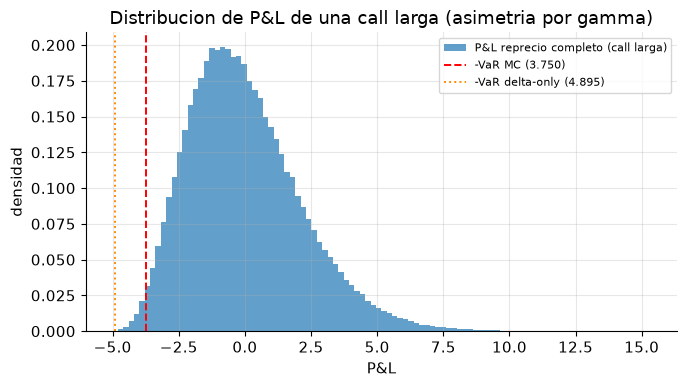

In [3]:
K, r, q, T = 100.0, 0.0, 0.0, 0.5
price0 = bs_price(S0, K, r, q, sigma, T, kind="call")
delta0 = bs_delta(S0, K, r, q, sigma, T, kind="call")

# VaR parametrico delta-only (ignora gamma): trata el P&L como lineal en el retorno del spot
sigma_pnl_delta = abs(delta0) * S0 * sigma * np.sqrt(h)
VaR_param_delta_only = z_alpha * sigma_pnl_delta

# VaR Monte Carlo: reprecio COMPLETO de la opcion tras simular el spot al horizonte h
S_h = S0 * np.exp((mu - 0.5 * sigma ** 2) * h + sigma * np.sqrt(h) * rng.standard_normal(n_hist))
price_h = np.array([bs_price(s, K, r, q, sigma, T - h, kind="call") for s in S_h])
pnl_option = price_h - price0
losses_option = -pnl_option
VaR_mc_option = np.quantile(losses_option, alpha)
ES_mc_option = losses_option[losses_option >= VaR_mc_option].mean()

print(f"VaR parametrico (delta-only, ignora gamma): {VaR_param_delta_only:.4f}")
print(f"VaR Monte Carlo (reprecio completo, con gamma): {VaR_mc_option:.4f}")
print(f"el modelo delta-only SOBREESTIMA el VaR de una posicion larga en gamma "
      f"(diff={VaR_param_delta_only-VaR_mc_option:.4f}) -- la convexidad amortigua perdidas extremas.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(pnl_option, bins=100, density=True, alpha=0.7, label="P&L reprecio completo (call larga)")
ax.axvline(-VaR_mc_option, color="red", ls="--", label=f"-VaR MC ({VaR_mc_option:.3f})")
ax.axvline(-VaR_param_delta_only, color="darkorange", ls=":", label=f"-VaR delta-only ({VaR_param_delta_only:.3f})")
ax.set_xlabel("P&L"); ax.set_ylabel("densidad")
ax.set_title("Distribucion de P&L de una call larga (asimetria por gamma)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## 3. Subaditividad de ES, y un contraejemplo de VaR

In [4]:
rho_corr = 0.3
Z = rng.standard_normal((n_hist, 2))
chol = np.array([[1.0, 0.0], [rho_corr, np.sqrt(1 - rho_corr ** 2)]])
Rmat = Z @ chol.T
loss1 = -100.0 * sigma * np.sqrt(h) * Rmat[:, 0]
loss2 = -80.0 * sigma * np.sqrt(h) * Rmat[:, 1]
loss_combo = loss1 + loss2


def es_at(losses, alpha):
    v = np.quantile(losses, alpha)
    return v, losses[losses >= v].mean()


_, es1 = es_at(loss1, alpha)
_, es2 = es_at(loss2, alpha)
_, es_combo = es_at(loss_combo, alpha)
subadditive_es = es_combo <= es1 + es2
print(f"ES1={es1:.3f}  ES2={es2:.3f}  ES(combinado)={es_combo:.3f}  "
      f"subaditivo (combinado<=suma)? {subadditive_es}")

ES1=10.655  ES2=8.564  ES(combinado)=15.542  subaditivo (combinado<=suma)? True


**Contraejemplo de no-subaditividad de VaR** (clásico, Artzner et al. 1999, a $\alpha=95\%$
-- distinto del $\alpha=99\%$ global del notebook, necesario para que la violacion aparezca): dos
posiciones independientes, cada una con 4% de probabilidad de una pérdida de 100
(96% de probabilidad de pérdida 0) — a $\alpha=95\%$, el VaR individual de CADA posición
es 0 (el percentil 95 cae en la rama "sin pérdida", ya que $P(\text{pérdida}>0)=4\%<5\%$).
Pero al combinar 2 posiciones independientes, $P(\text{al menos una pérdida})=1-0.96^2\approx7.8\%>5\%$
— el VaR del portafolio combinado salta a 100, MAYOR que la suma de los VaR individuales
(0+0=0).

In [5]:
p_default = 0.04
L_loss = 100.0
n_binary = 2_000_000
rng_binary = np.random.default_rng(123)  # rng dedicado -- desacopla este chequeo del estado de rng usado arriba
def1 = rng_binary.uniform(size=n_binary) < p_default
def2 = rng_binary.uniform(size=n_binary) < p_default
loss_d1 = def1 * L_loss
loss_d2 = def2 * L_loss
loss_dcombo = loss_d1 + loss_d2

alpha_demo = 0.95  # el contraejemplo clasico exige alpha=95%, no el alpha=99% global del notebook
                   # (a 99% ambos VaR individuales YA son 100, y no hay violacion que mostrar)
VaR_d1 = np.quantile(loss_d1, alpha_demo)
VaR_d2 = np.quantile(loss_d2, alpha_demo)
VaR_dcombo = np.quantile(loss_dcombo, alpha_demo)
var_fails_subadditivity = VaR_dcombo > VaR_d1 + VaR_d2

print(f"VaR individual 1: {VaR_d1}, VaR individual 2: {VaR_d2}, suma: {VaR_d1+VaR_d2}")
print(f"VaR combinado: {VaR_dcombo}")
print(f"VaR FALLA subaditividad (combinado > suma): {var_fails_subadditivity}")

VaR individual 1: 0.0, VaR individual 2: 0.0, suma: 0.0
VaR combinado: 100.0
VaR FALLA subaditividad (combinado > suma): True


## 4. Validación

In [6]:
check1 = ES_param >= VaR_param and ES_hist >= VaR_hist
print(f"1. ES >= VaR en ambos portafolios (parametrico e historico): {check1}")

rel_diff_linear = abs(VaR_param - VaR_hist) / VaR_param
check2 = rel_diff_linear < 0.02
print(f"2. VaR parametrico vs historico (portafolio lineal), diff relativa={rel_diff_linear:.2%} (<2%? {check2})")

check3 = subadditive_es
print(f"3. subaditividad de ES verificada (dos posiciones correlacionadas): {check3}")

check4 = var_fails_subadditivity
print(f"4. contraejemplo: VaR SI falla subaditividad (verificacion negativa, el punto pedagogico): {check4}")

assert check1
assert check2
assert check3
assert check4
print("\nValidacion completa: 4/4 dentro de tolerancia.")

1. ES >= VaR en ambos portafolios (parametrico e historico): True
2. VaR parametrico vs historico (portafolio lineal), diff relativa=0.06% (<2%? True)
3. subaditividad de ES verificada (dos posiciones correlacionadas): True
4. contraejemplo: VaR SI falla subaditividad (verificacion negativa, el punto pedagogico): True

Validacion completa: 4/4 dentro de tolerancia.


## Referencias

- Jorion, P. (2006). *Value at Risk: The New Benchmark for Managing Financial Risk*, 3rd
  ed.
- Artzner, P., Delbaen, F., Eber, J.M., Heath, D. (1999). *Coherent Measures of Risk*.
  Mathematical Finance, 9(3), 203-228.